# 06 Hidden Markov Model

This notebook applies a Gaussian Hidden Markov Model (HMM) to identify latent market regimes in the cryptocurrency market. Unlike the k-Means clustering in notebook `05`, the HMM is a generative sequence model that explicitly captures the temporal ordering of observations and the probability of transitioning between hidden states over time.

## Task

Unsupervised regime detection: assign each trading day to one of $K$ latent market states (e.g. low-volatility bull regime, high-volatility bear regime) based on the same daily market feature matrix used in notebook `05`.

## Method

A Gaussian HMM with diagonal covariance matrices is fitted to the standardized daily feature matrix. The model is trained via the Baum-Welch (EM) algorithm. The number of hidden states is selected by comparing BIC scores across candidate values of $K \in \{2, 3, 4, 5, 6, 7\}$. To reduce the risk of converging to a local optimum, the final model is fitted `N_RESTARTS` times with different random seeds and the run with the highest log-likelihood is kept. The Viterbi algorithm then decodes the most likely state sequence for the full observation period.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_HMM
from src.utils.plot_config import COIN_COLORS, apply_plot_style

warnings.filterwarnings("ignore", category=DeprecationWarning)

apply_plot_style()

# Re-apply background settings after seaborn initializes,
# as seaborn can override these during its own setup.
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

get_or_create_experiment(EXPERIMENT_HMM)
mlflow.set_experiment(EXPERIMENT_HMM)

/home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/mlruns/590675346676737577', creation_time=1777232281102, experiment_id='590675346676737577', last_update_time=1777232281102, lifecycle_stage='active', name='hmm_regime_detection', tags={}, trace_location=None, workspace='default'>

## Configuration
All paths and hyperparameter search ranges are defined here so they can be adjusted in one place.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_PROCESSED_DIR     = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

# Input paths (outputs from notebook 02)
FEATURES_LONG_ALIGNED_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"

# Output path (regime labels are model outputs, not processed features)
HMM_REGIME_LABELS_OUTPUT_PATH = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels.csv"

# Model selection range
N_STATES_RANGE = range(2, 8)  # candidate values: 2, 3, 4, 5, 6, 7

N_ITER             = 500     # maximum EM iterations
N_RESTARTS_SWEEP   = 5       # random restarts per K during model selection
N_RESTARTS         = 10      # random restarts for the final model fit
COVARIANCE_TYPE    = "diag"  # diagonal covariance — fewer parameters than "full", more stable in higher dimensions

## Load data

In [3]:
features_long_df = pd.read_csv(FEATURES_LONG_ALIGNED_PATH, parse_dates=["Date"])

print("Features long shape:", features_long_df.shape)
print("Date range:", features_long_df["Date"].min().date(), "to", features_long_df["Date"].max().date())

Features long shape: (13044, 15)
Date range: 2020-04-10 to 2026-03-23


## Build the daily market feature matrix
The same aggregation logic used in notebook `05` is applied here. Each row represents one trading day. The feature matrix summarizes market-wide behavior using cross-sectional statistics and macro variables.

In [4]:
from src.features.daily import build_daily_market_features

In [5]:
daily_features_df = build_daily_market_features(features_long_df)
daily_features_clean_df = daily_features_df.dropna().copy()

print("Daily features shape before dropping NaNs:", daily_features_df.shape)
print("Daily features shape after  dropping NaNs:", daily_features_clean_df.shape)
print(f"Dropped {len(daily_features_df) - len(daily_features_clean_df)} rows")

daily_features_clean_df.head()

Daily features shape before dropping NaNs: (2174, 9)
Daily features shape after  dropping NaNs: (2144, 9)
Dropped 30 rows


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
Date,,,,,,,,,
2020-05-10,-0.107129,0.014830,0.047262,0.722147,0.034981,0.000000,0.000000,0.000000,0.000000
2020-05-11,-0.020996,0.010383,0.046322,0.729057,0.033585,0.005101,-0.008575,0.000133,-0.014762
2020-05-12,0.030535,0.012004,0.045797,0.734064,0.032777,-0.003097,0.005353,-0.020713,0.180991
2020-05-13,0.033102,0.014469,0.045399,0.742890,0.031832,0.003097,0.005558,-0.017617,0.065597
2020-05-14,0.023250,0.015059,0.044588,0.746671,0.030742,0.002292,0.014021,0.011459,-0.078697


## Preprocessing
The features are standardized before fitting the HMM. Although the Gaussian HMM learns its own emission means and covariances per state, standardizing ensures that no single feature dominates the covariance structure due to scale differences.

In [6]:
feature_columns = daily_features_clean_df.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_features_clean_df[feature_columns])

print("Scaled feature matrix shape:", X_scaled.shape)
print("\nFeature means after scaling (should be ~0):")
print(pd.Series(X_scaled.mean(axis=0), index=feature_columns).round(6))

Scaled feature matrix shape: (2144, 9)

Feature means after scaling (should be ~0):
mean_log_return     -0.0
return_dispersion    0.0
mean_volatility     -0.0
mean_btc_corr       -0.0
mean_idio_vol       -0.0
dxy_log_return       0.0
gold_log_return      0.0
sp500_log_return     0.0
vix_log_return      -0.0
dtype: float64


## Model selection
A separate GaussianHMM is fitted for each candidate value of $K$. Model complexity is penalized using the Bayesian Information Criterion (BIC):

$$
\text{BIC} = -2 \cdot \log \hat{L} + p \cdot \log(T)
$$

where $\hat{L}$ is the maximized likelihood, $p$ is the number of free parameters, and $T$ is the number of observations.

A lower BIC indicates a better balance between fit and complexity.

In [7]:
def count_hmm_parameters(model: hmm.GaussianHMM, n_features: int) -> int:
    """
    Count the number of free parameters in a fitted GaussianHMM.

    For a model with K states and D features:
      - Initial state probabilities: K - 1
      - Transition matrix:           K * (K - 1)
      - Emission means:              K * D
      - Emission covariances:        depends on covariance_type
            "full":      K * D * (D + 1) / 2  (symmetric matrix per state)
            "diag":      K * D                (one variance per feature per state)
            "tied":      D * (D + 1) / 2      (one shared full matrix)
            "spherical": K                    (one variance per state)
    """
    k = model.n_components
    d = n_features
    cov_type = model.covariance_type
    if cov_type == "full":
        cov_params = k * d * (d + 1) // 2
    elif cov_type == "diag":
        cov_params = k * d
    elif cov_type == "tied":
        cov_params = d * (d + 1) // 2
    elif cov_type == "spherical":
        cov_params = k
    else:
        raise ValueError(f"Unknown covariance_type: {cov_type}")
    return (k - 1) + k * (k - 1) + k * d + cov_params

In [8]:
FEATURES_USED = ",".join(feature_columns)
T, D = X_scaled.shape

sweep_results = []

for n_states in N_STATES_RANGE:
    with mlflow.start_run(run_name=f"hmm_sweep_k={n_states}"):
        best_model_k = None
        best_score_k = -np.inf
        best_seed_k  = None
        n_converged  = 0

        for restart in range(N_RESTARTS_SWEEP):
            candidate = hmm.GaussianHMM(
                n_components=n_states,
                covariance_type=COVARIANCE_TYPE,
                n_iter=N_ITER,
                random_state=restart,
            )
            candidate.fit(X_scaled)
            if candidate.monitor_.converged:
                n_converged += 1
            score = candidate.score(X_scaled)
            if score > best_score_k:
                best_score_k = score
                best_model_k = candidate
                best_seed_k  = restart

        log_likelihood = best_score_k
        n_params = count_hmm_parameters(best_model_k, D)
        bic = -2 * log_likelihood + n_params * np.log(T)
        aic = -2 * log_likelihood + 2 * n_params

        mlflow.log_param("algorithm", "gaussian_hmm")
        mlflow.log_param("n_states", n_states)
        mlflow.log_param("covariance_type", COVARIANCE_TYPE)
        mlflow.log_param("n_iter", N_ITER)
        mlflow.log_param("n_restarts", N_RESTARTS_SWEEP)
        mlflow.log_param("best_seed", best_seed_k)
        mlflow.log_param("n_observations", T)
        mlflow.log_param("n_features", D)
        mlflow.log_param("features_used", FEATURES_USED)
        mlflow.log_param("n_free_params", n_params)
        mlflow.log_param("dataset", "aligned_6_assets_from_2020")

        mlflow.log_metric("log_likelihood", log_likelihood)
        mlflow.log_metric("bic", bic)
        mlflow.log_metric("aic", aic)
        mlflow.log_metric("n_converged_restarts", n_converged)

        sweep_results.append({
            "n_states": n_states,
            "log_likelihood": log_likelihood,
            "n_params": n_params,
            "bic": bic,
            "aic": aic,
            "converged": f"{n_converged}/{N_RESTARTS_SWEEP}",
        })

        print(
            f"n_states={n_states}  log_likelihood={log_likelihood:.2f}  "
            f"BIC={bic:.2f}  AIC={aic:.2f}  converged={n_converged}/{N_RESTARTS_SWEEP}"
        )

sweep_df = pd.DataFrame(sweep_results).set_index("n_states")
sweep_df

n_states=2  log_likelihood=-23158.71  BIC=46616.56  AIC=46395.42  converged=5/5
n_states=3  log_likelihood=-10742.37  BIC=21960.31  AIC=21608.74  converged=5/5
n_states=4  log_likelihood=-9832.68  BIC=20332.68  AIC=19839.35  converged=5/5
n_states=5  log_likelihood=-9194.36  BIC=19263.14  AIC=18616.71  converged=5/5


Model is not converging.  Current: -8531.697759225159 is not greater than -8531.684400901488. Delta is -0.013358323671127437


n_states=6  log_likelihood=-8531.71  BIC=18160.28  AIC=17349.41  converged=5/5
n_states=7  log_likelihood=-8115.11  BIC=17564.88  AIC=16578.23  converged=5/5


,log_likelihood,n_params,bic,aic,converged
n_states,,,,,
2,-23158.708191,39,46616.563095,46395.416382,5/5
3,-10742.371259,62,21960.309086,21608.742517,5/5
4,-9832.675192,87,20332.677665,19839.350383,5/5
5,-9194.355540,114,19263.139932,18616.711080,5/5
6,-8531.706542,143,18160.284363,17349.413084,5/5
7,-8115.114819,174,17564.884200,16578.229637,5/5


## Model selection plot

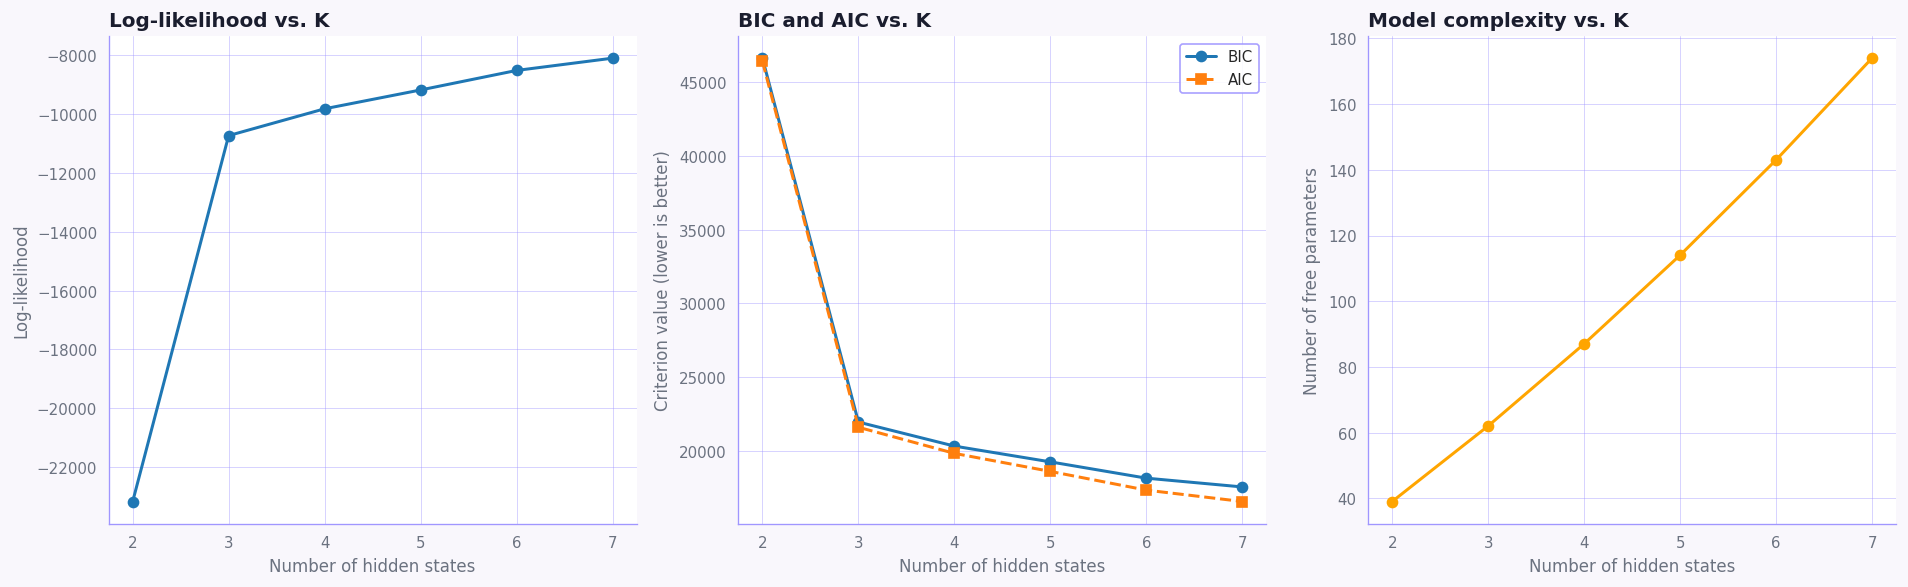

Best K by BIC: 7


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df.index, sweep_df["log_likelihood"], "o-")
axes[0].set_xlabel("Number of hidden states")
axes[0].set_ylabel("Log-likelihood")
axes[0].set_title("Log-likelihood vs. K")
axes[0].set_xticks(list(N_STATES_RANGE))

axes[1].plot(sweep_df.index, sweep_df["bic"], "o-", label="BIC")
axes[1].plot(sweep_df.index, sweep_df["aic"], "s--", label="AIC")
axes[1].set_xlabel("Number of hidden states")
axes[1].set_ylabel("Criterion value (lower is better)")
axes[1].set_title("BIC and AIC vs. K")
axes[1].set_xticks(list(N_STATES_RANGE))
axes[1].legend()

axes[2].plot(sweep_df.index, sweep_df["n_params"], "o-", color="orange")
axes[2].set_xlabel("Number of hidden states")
axes[2].set_ylabel("Number of free parameters")
axes[2].set_title("Model complexity vs. K")
axes[2].set_xticks(list(N_STATES_RANGE))

plt.tight_layout()
plt.show()

best_k_bic = int(sweep_df["bic"].idxmin())
print(f"Best K by BIC: {best_k_bic}")

## Final model

The final model uses $K=2$ hidden states. BIC continues to decrease as $K$ grows because the diagonal-covariance penalty is light relative to the gains in log-likelihood from adding states, so BIC alone is not a sufficient criterion. Three considerations argue for $K=2$ as the principled choice:

1. **Interpretability** — a binary regime split maps cleanly onto the canonical "calm vs volatile" market view that downstream analysis in `08_diversification.ipynb` (per-regime portfolio Sharpe) and `07_classification.ipynb` (per-regime classifier accuracy) relies on.
2. **Persistence** — the $K=2$ fit produces transition diagonals of roughly 0.94 and 0.97, corresponding to expected regime durations of about 16 and 36 days respectively, well into the persistent range.
3. **Consistency with the K-Means baseline** in notebook `05` (also $K=2$), which keeps the comparison between the two methods about model class HMM's transition prior versus a static partition rather than mixing it with a difference.

Notebook `07` independently sweeps $K \in \{2, 3, 4\}$ for downstream prediction and picks $K=2$ as the best regime granularity for the classifier external validation that the two-state choice is not just statistically convenient but predictively useful.

To reduce the risk of the Baum-Welch algorithm converging to a local optimum, the model is fitted `N_RESTARTS` times with different random seeds. The run with the highest log-likelihood is kept. The Viterbi algorithm then decodes the most likely hidden state sequence for every trading day.

In [10]:

FINAL_N_STATES = 2

best_model  = None
best_score  = -np.inf
best_seed   = None
n_converged = 0

for restart in range(N_RESTARTS):
    candidate = hmm.GaussianHMM(
        n_components=FINAL_N_STATES,
        covariance_type=COVARIANCE_TYPE,
        n_iter=N_ITER,
        random_state=restart,
    )
    candidate.fit(X_scaled)
    if candidate.monitor_.converged:
        n_converged += 1
    score = candidate.score(X_scaled)
    if score > best_score:
        best_score = score
        best_model = candidate
        best_seed  = restart

final_model   = best_model
regime_labels = final_model.predict(X_scaled)

# Define state colors here so all downstream plot cells are self-contained and do not depend on a specific cell having run first.
colors = plt.cm.Set1(np.linspace(0, 0.8, FINAL_N_STATES))

log_likelihood = final_model.score(X_scaled)
n_params = count_hmm_parameters(final_model, D)
bic = -2 * log_likelihood + n_params * np.log(T)
aic = -2 * log_likelihood + 2 * n_params

# Open the MLflow run without a context manager so it stays open across cells until the output file is saved and logged.
final_run = mlflow.start_run(run_name=f"hmm_final_k={FINAL_N_STATES}")

mlflow.log_param("algorithm", "gaussian_hmm")
mlflow.log_param("n_states", FINAL_N_STATES)
mlflow.log_param("covariance_type", COVARIANCE_TYPE)
mlflow.log_param("n_iter", N_ITER)
mlflow.log_param("n_restarts", N_RESTARTS)
mlflow.log_param("best_seed", best_seed)
mlflow.log_param("n_observations", T)
mlflow.log_param("n_features", D)
mlflow.log_param("features_used", FEATURES_USED)
mlflow.log_param("n_free_params", n_params)
mlflow.log_param("dataset", "aligned_6_assets_from_2020")
mlflow.set_tag("stage", "final")

mlflow.log_metric("log_likelihood", log_likelihood)
mlflow.log_metric("bic", bic)
mlflow.log_metric("aic", aic)
mlflow.log_metric("n_converged_restarts", n_converged)

for state_id, count in pd.Series(regime_labels).value_counts().sort_index().items():
    mlflow.log_metric(f"state_{state_id}_size", int(count))

FINAL_RUN_ID = final_run.info.run_id

print(f"Final HMM with K={FINAL_N_STATES}")
print(f"Best restart seed: {best_seed}")
print(f"Converged:         {n_converged}/{N_RESTARTS}")
print(f"Log-likelihood:    {log_likelihood:.4f}")
print(f"BIC:               {bic:.2f}")
print(f"AIC:               {aic:.2f}")
print(f"MLflow run_id:     {FINAL_RUN_ID}")
print("\nRegime sizes:")
print(pd.Series(regime_labels).value_counts().sort_index())

Final HMM with K=2
Best restart seed: 2
Converged:         10/10
Log-likelihood:    -23158.7082
BIC:               46616.56
AIC:               46395.42
MLflow run_id:     84a04683135c464abfc856d763e7e0f3

Regime sizes:
0     674
1    1470
Name: count, dtype: int64


## Regime analysis
The emission parameters (means and covariances) of each hidden state are inspected to attach economic interpretations to the regimes.

In [11]:
# Emission means per state in the original (unscaled) feature space
emission_means_scaled = pd.DataFrame(
    final_model.means_,
    columns=feature_columns,
    index=[f"State {i}" for i in range(FINAL_N_STATES)],
)

# Invert scaling to get interpretable units
emission_means_orig = pd.DataFrame(
    scaler.inverse_transform(final_model.means_),
    columns=feature_columns,
    index=[f"State {i}" for i in range(FINAL_N_STATES)],
)

print("Emission means (original scale):")
emission_means_orig.round(4)

Emission means (original scale):


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
State 0,0.0029,0.0386,0.0584,0.6172,0.0456,0.0,0.0001,-0.0001,0.0034
State 1,0.0007,0.0171,0.0312,0.7074,0.0211,-0.0,0.0006,0.0006,-0.0016


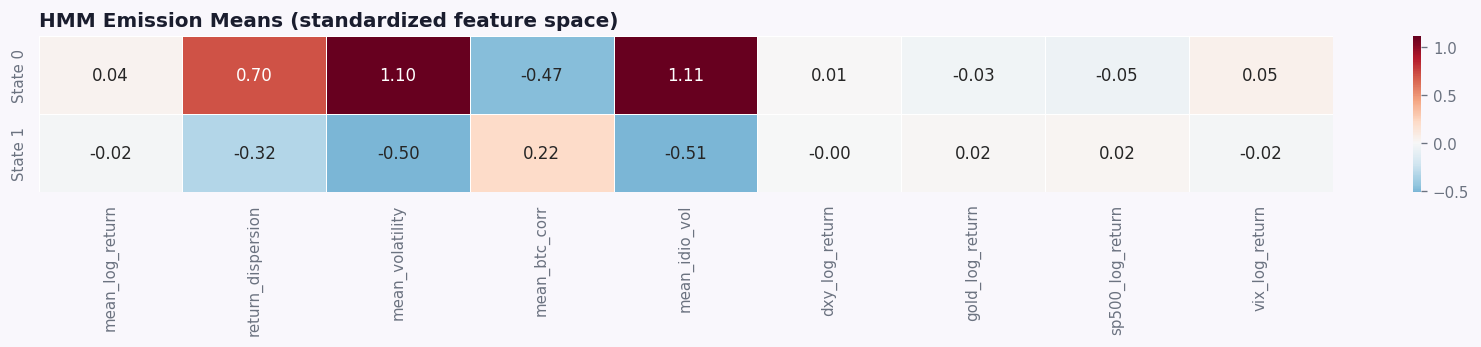

In [12]:
# Heatmap of emission means in the standardized feature space for easier comparison
fig, ax = plt.subplots(figsize=(14, max(3, FINAL_N_STATES + 1)))
sns.heatmap(
    emission_means_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("HMM Emission Means (standardized feature space)")
plt.tight_layout()
plt.show()

## Regime labels over time
The decoded state sequence is plotted alongside the BTC price to visually assess whether the detected regimes correspond to recognizable market phases.

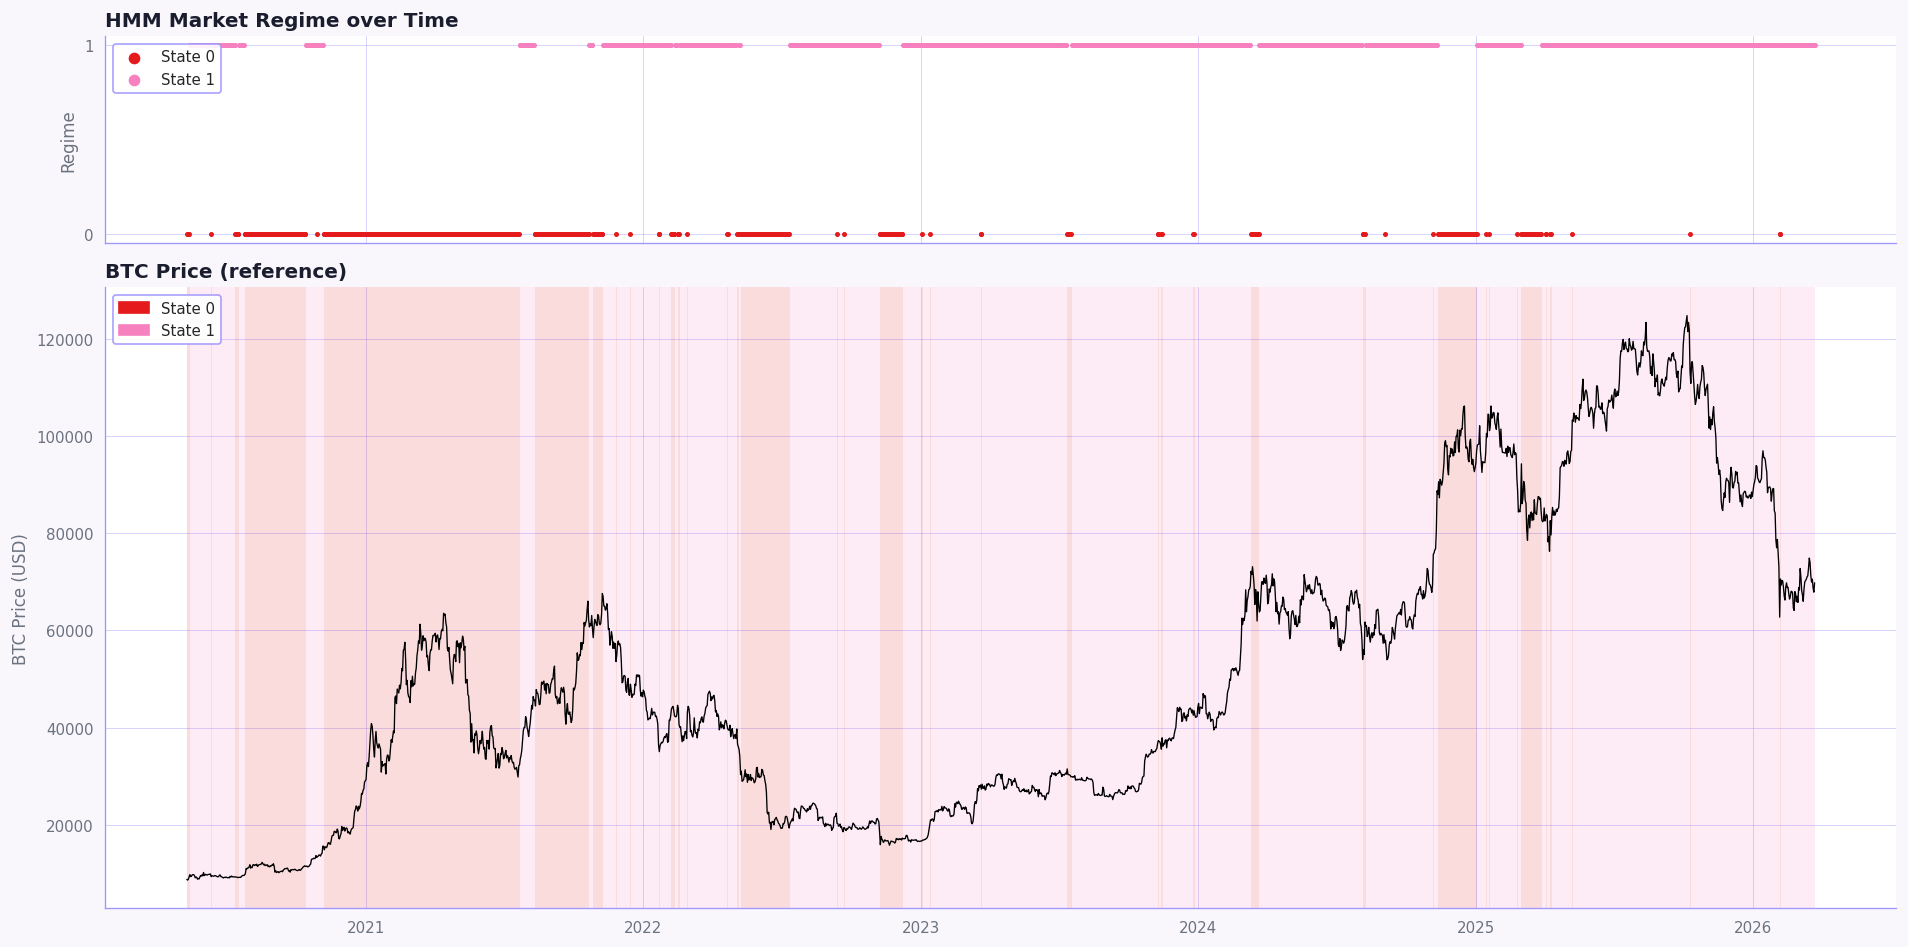

In [13]:
daily_features_clean_df["hmm_regime"] = regime_labels

dates = daily_features_clean_df.index

fig, axes = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True, gridspec_kw={"height_ratios": [1, 3]}
)

# Top panel: regime sequence
for state in range(FINAL_N_STATES):
    mask = regime_labels == state
    axes[0].scatter(
        dates[mask], regime_labels[mask], color=colors[state], s=4, label=f"State {state}"
    )
axes[0].set_ylabel("Regime")
axes[0].set_yticks(range(FINAL_N_STATES))
axes[0].set_title("HMM Market Regime over Time")
axes[0].legend(loc="upper left", markerscale=3)

# Bottom panel: BTC price with regime shading
btc_close = pd.read_csv(
    DATA_PROCESSED_DIR / "crypto_wide_close_aligned.csv",
    parse_dates=["Date"],
    index_col="Date",
)["BTC"]
btc_close_filtered = btc_close.loc[dates[0]:dates[-1]]

axes[1].plot(btc_close_filtered.index, btc_close_filtered.values, color="black", linewidth=0.8)
axes[1].set_ylabel("BTC Price (USD)")
axes[1].set_title("BTC Price (reference)")

for i in range(len(dates) - 1):
    axes[1].axvspan(
        dates[i], dates[i + 1],
        alpha=0.15,
        color=colors[regime_labels[i]],
        linewidth=0,
    )

legend_patches = [mpatches.Patch(color=colors[s], label=f"State {s}") for s in range(FINAL_N_STATES)]
axes[1].legend(handles=legend_patches, loc="upper left")

plt.tight_layout()
plt.show()

## Transition matrix
The learned transition matrix $A$ gives the probability of moving from state $i$ to state $j$ on consecutive trading days. High diagonal values indicate that regimes are persistent.

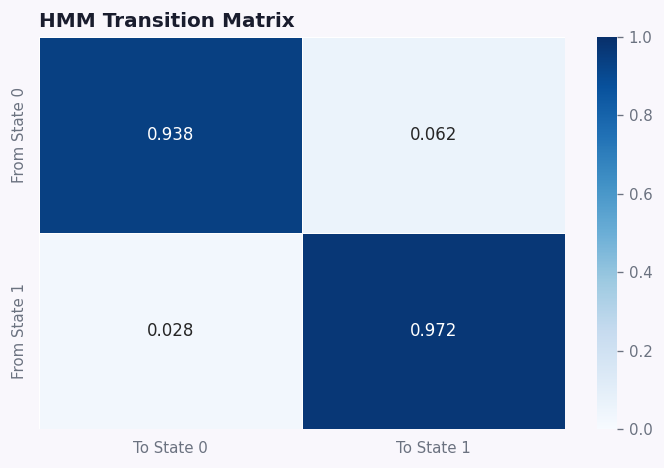

Transition matrix:
              To State 0  To State 1
From State 0      0.9375      0.0625
From State 1      0.0278      0.9722


In [14]:
transition_df = pd.DataFrame(
    final_model.transmat_,
    index=[f"From State {i}" for i in range(FINAL_N_STATES)],
    columns=[f"To State {j}" for j in range(FINAL_N_STATES)],
)

fig, ax = plt.subplots(figsize=(6, max(4, FINAL_N_STATES + 2)))
sns.heatmap(
    transition_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("HMM Transition Matrix")
plt.tight_layout()
plt.show()

print("Transition matrix:")
print(transition_df.round(4))

## Regime persistence
Expected regime duration is computed from the learned self-transition probabilities:

$$
\mathbb{E}[\text{duration of state } i] = \frac{1}{1 - A_{ii}}
$$

In [15]:
regime_series = daily_features_clean_df["hmm_regime"]
transitions = (regime_series != regime_series.shift(1)).sum() - 1

total_days = len(regime_series)
print(f"Total trading days:       {total_days}")
print(f"Total regime transitions: {transitions}")
print(f"Average regime duration:  {total_days / (transitions + 1):.1f} days")

print("\nExpected duration per state (from learned self-transition probabilities):")
for i in range(FINAL_N_STATES):
    p_self = final_model.transmat_[i, i]
    expected_duration = 1.0 / (1.0 - p_self) if p_self < 1.0 else float("inf")
    print(f"  State {i}: {expected_duration:.1f} days  (p_self={p_self:.4f})")

Total trading days:       2144
Total regime transitions: 81
Average regime duration:  26.1 days

Expected duration per state (from learned self-transition probabilities):
  State 0: 16.0 days  (p_self=0.9375)
  State 1: 36.0 days  (p_self=0.9722)


## Feature distributions by regime
Histograms of the most informative features across regimes confirm whether the detected states are economically meaningful.

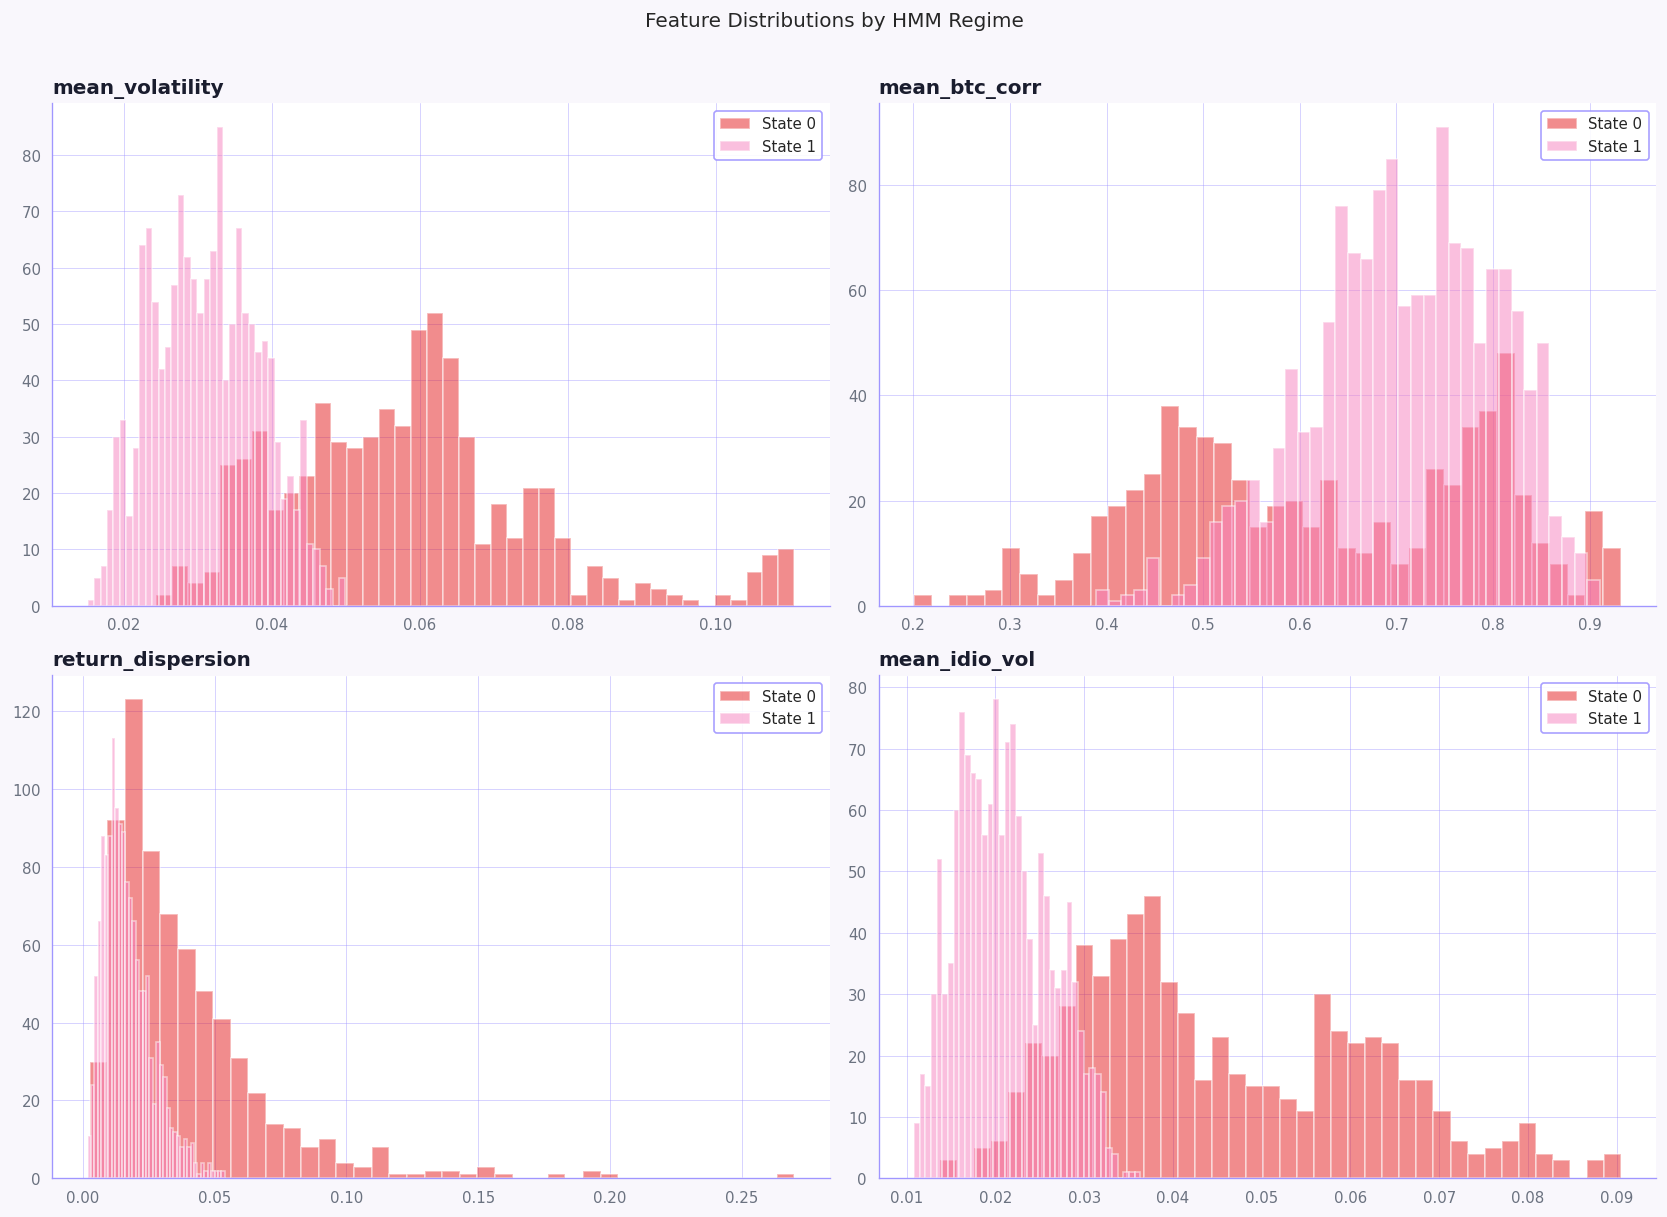

In [16]:
key_features = ["mean_volatility", "mean_btc_corr", "return_dispersion", "mean_idio_vol"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for state in range(FINAL_N_STATES):
        mask = daily_features_clean_df["hmm_regime"] == state
        axes[i].hist(
            daily_features_clean_df.loc[mask, feat],
            bins=40,
            alpha=0.5,
            label=f"State {state}",
            color=colors[state],
        )
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Feature Distributions by HMM Regime", y=1.01)
plt.tight_layout()
plt.show()

## Posterior state probabilities
The posterior probability of being in each state at every time step is computed with the forward-backward algorithm. Plotting these probabilities shows how certain the model is about the regime assignment on each day.

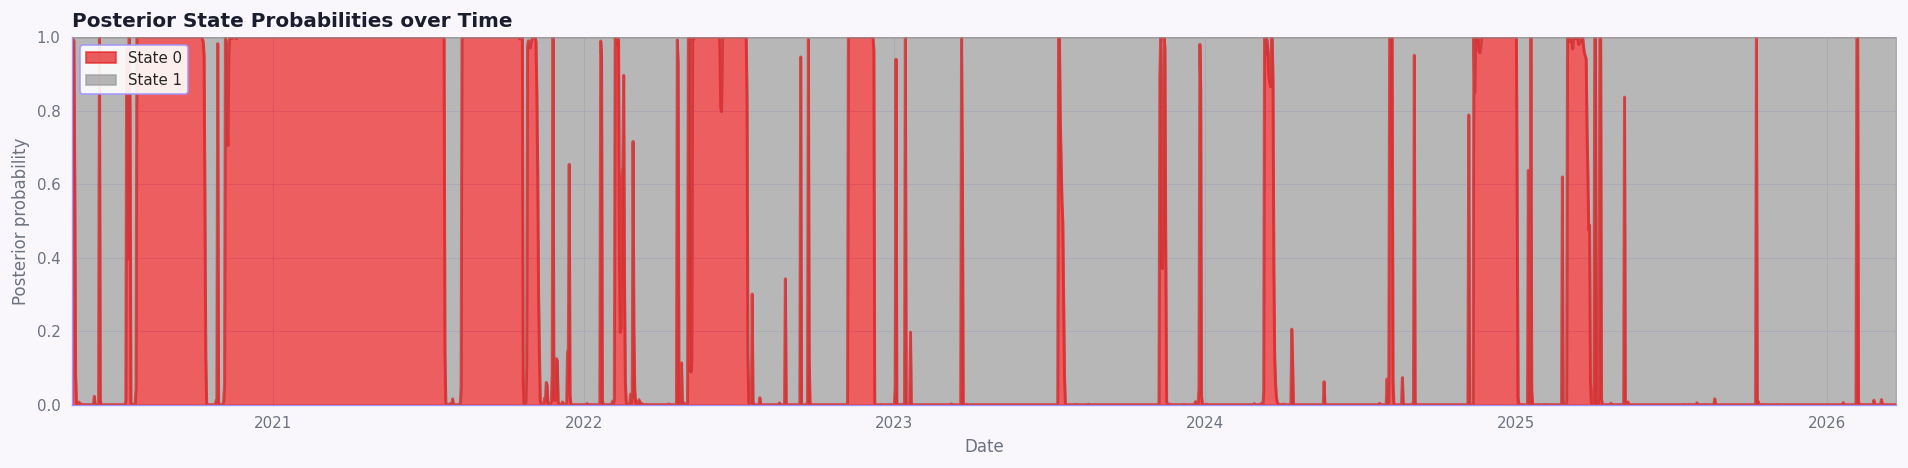

In [17]:
posterior_probs = final_model.predict_proba(X_scaled)

posterior_df = pd.DataFrame(
    posterior_probs,
    index=daily_features_clean_df.index,
    columns=[f"State {i}" for i in range(FINAL_N_STATES)],
)

fig, ax = plt.subplots(figsize=(16, 4))
posterior_df.plot.area(ax=ax, alpha=0.7, colormap="Set1")
ax.set_ylabel("Posterior probability")
ax.set_xlabel("Date")
ax.set_title("Posterior State Probabilities over Time")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Comparison with K-Means baseline

The K-Means model from notebook `05` is fit on the same daily feature matrix, the same date range, and the same number of states ($K=2$) as the HMM. Holding $K$ constant isolates the model-class effect: any difference in stability or label assignment comes from K-Means treating each day independently versus the HMM modeling temporal transitions explicitly, not from one method using a finer or coarser partition than the other.

The comparison reports:
- **Adjusted Rand Index** and **Normalized Mutual Information** — agreement between the two label sequences (invariant to label permutation; the same $K=2$ with different state-ID assignments still compares correctly).
- **Regime stability** — number of transitions and average regime duration for each method. With $K$ matched, the HMM should be at least as sticky as K-Means; if it is not, the transition prior is being overpowered by the emission term.
- **Cross-tabulation** — how each HMM state distributes across the K-Means partition.
- **Side-by-side timeline** — both regime sequences plotted against BTC price for visual inspection.

In [18]:
KMEANS_LABELS_PATH = DATA_PROCESSED_DIR / "regime_labels_baseline.csv"
kmeans_labels_df = (
    pd.read_csv(KMEANS_LABELS_PATH, parse_dates=["Date"], index_col="Date")
    .rename(columns={"regime": "kmeans_regime"})
)

comparison_df = (
    daily_features_clean_df[["hmm_regime"]]
    .join(kmeans_labels_df, how="inner")
)

print(f"Aligned rows:     {len(comparison_df)}")
print(f"K-Means clusters: {comparison_df['kmeans_regime'].nunique()}")
print(f"HMM states:       {comparison_df['hmm_regime'].nunique()}")
print(f"Date range:       {comparison_df.index.min().date()} to {comparison_df.index.max().date()}")

Aligned rows:     2144
K-Means clusters: 2
HMM states:       2
Date range:       2020-05-10 to 2026-03-23


In [19]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(comparison_df["kmeans_regime"], comparison_df["hmm_regime"])
nmi = normalized_mutual_info_score(comparison_df["kmeans_regime"], comparison_df["hmm_regime"])

def regime_stats(labels: pd.Series) -> dict:
    n_transitions = int((labels != labels.shift(1)).sum() - 1)
    n_total = len(labels)
    return {
        "n_states": int(labels.nunique()),
        "n_transitions": n_transitions,
        "avg_duration_days": round(n_total / (n_transitions + 1), 1),
    }

stability_df = pd.DataFrame({
    "K-Means": regime_stats(comparison_df["kmeans_regime"]),
    "HMM":     regime_stats(comparison_df["hmm_regime"]),
}).T

# Log agreement and stability metrics under the open final HMM run
mlflow.log_metric("vs_kmeans_ari", ari)
mlflow.log_metric("vs_kmeans_nmi", nmi)
mlflow.log_metric("hmm_n_transitions", int(stability_df.loc["HMM", "n_transitions"]))
mlflow.log_metric("hmm_avg_duration_days", float(stability_df.loc["HMM", "avg_duration_days"]))

print(f"Adjusted Rand Index:           {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")
print()
print("Regime stability comparison:")
stability_df

Adjusted Rand Index:           0.4810
Normalized Mutual Information: 0.4488

Regime stability comparison:


,n_states,n_transitions,avg_duration_days
K-Means,2.0,66.0,32.0
HMM,2.0,81.0,26.1


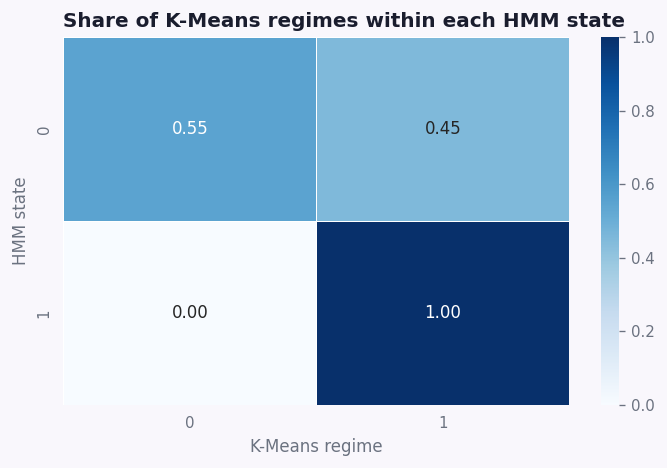

Row-normalized cross-tabulation:
K-Means regime      0      1
HMM state                   
0               0.547  0.453
1               0.000  1.000


In [20]:
crosstab = pd.crosstab(
    comparison_df["hmm_regime"],
    comparison_df["kmeans_regime"],
    rownames=["HMM state"],
    colnames=["K-Means regime"],
    normalize="index",
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Share of K-Means regimes within each HMM state")
plt.tight_layout()
plt.show()

print("Row-normalized cross-tabulation:")
print(crosstab.round(3))

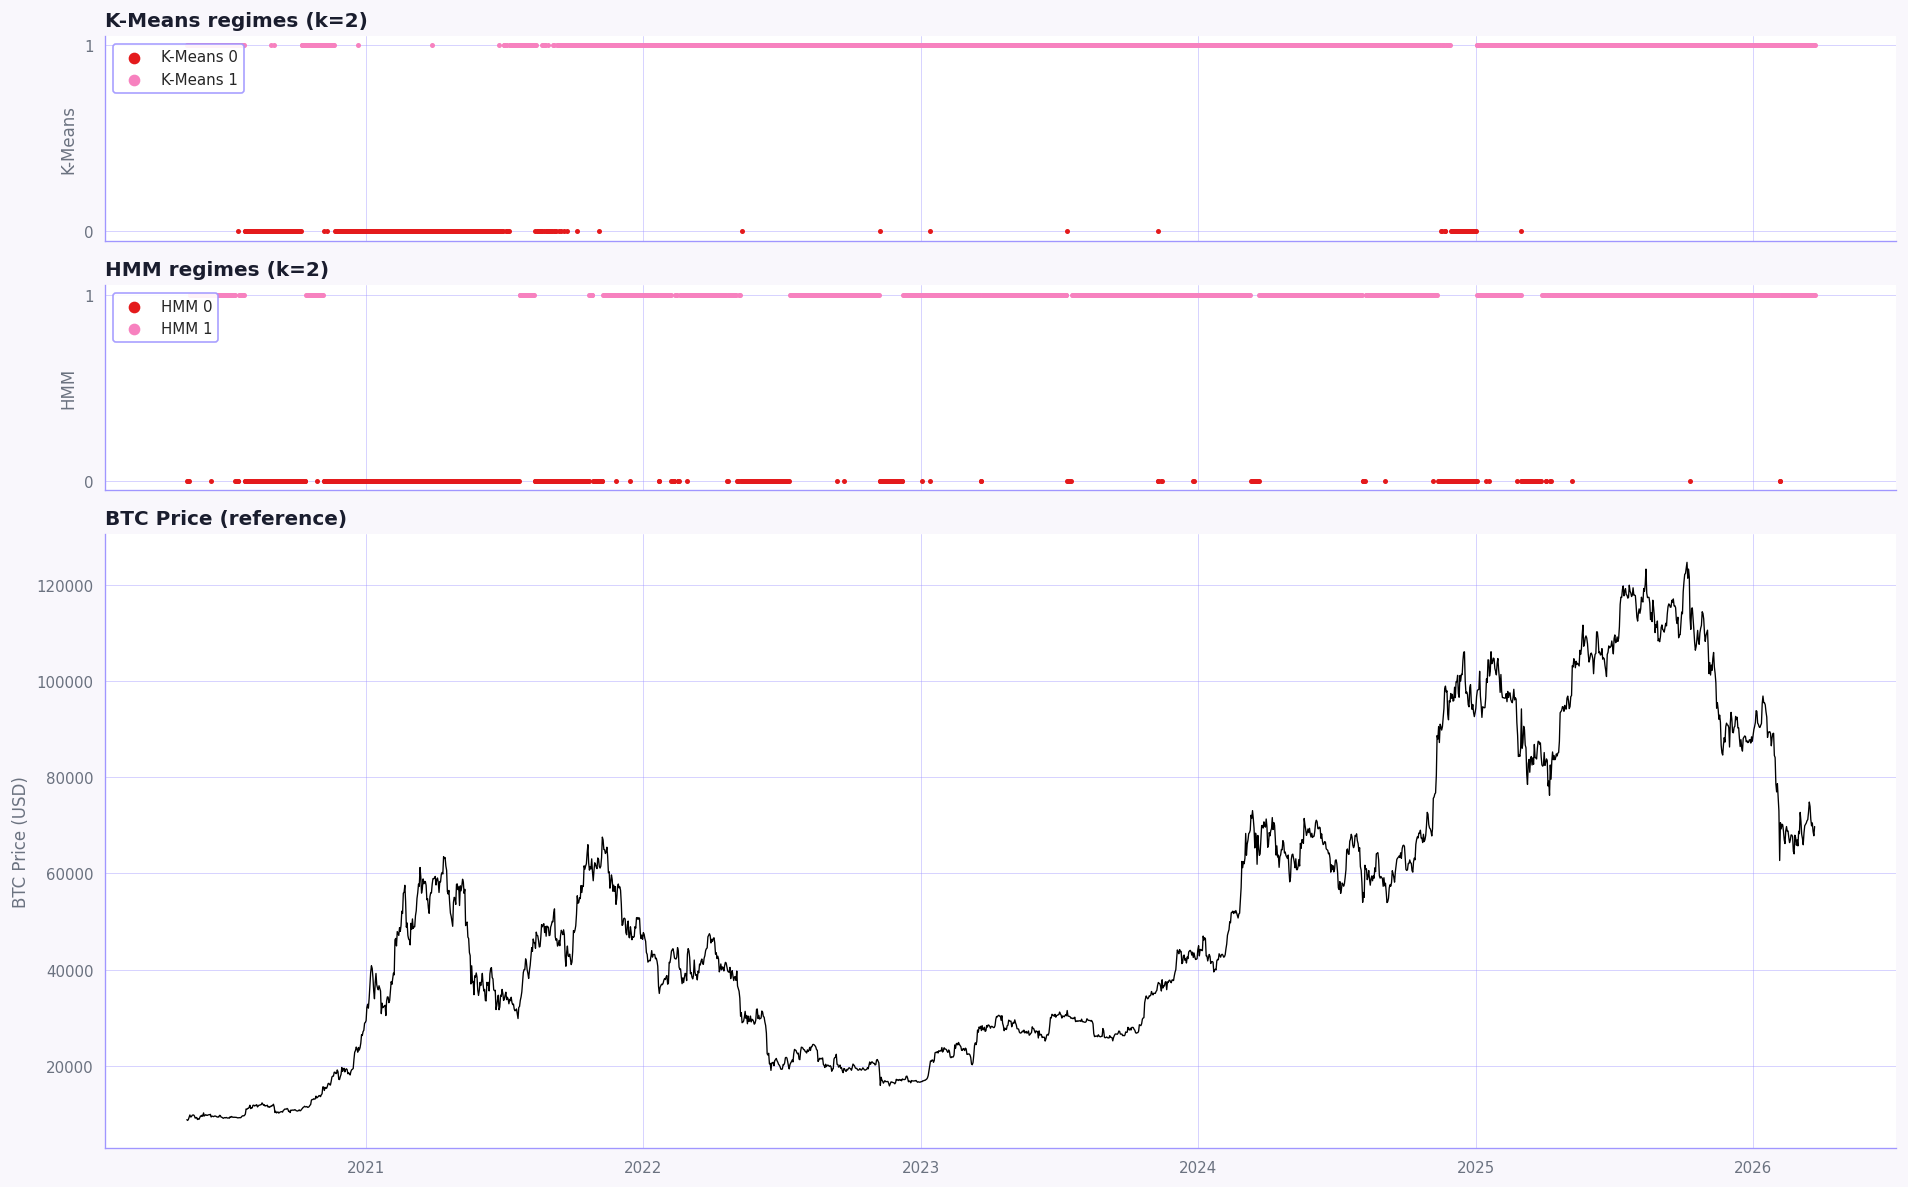

In [21]:
btc_close = pd.read_csv(
    DATA_PROCESSED_DIR / "crypto_wide_close_aligned.csv",
    parse_dates=["Date"],
    index_col="Date",
)["BTC"]

dates_cmp = comparison_df.index
n_kmeans = comparison_df["kmeans_regime"].nunique()
kmeans_colors = plt.cm.Set1(np.linspace(0, 0.8, n_kmeans))

fig, axes = plt.subplots(
    3, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [1, 1, 3]}
)

# K-Means panel
for state in range(n_kmeans):
    mask = comparison_df["kmeans_regime"] == state
    axes[0].scatter(
        dates_cmp[mask], comparison_df.loc[mask, "kmeans_regime"],
        color=kmeans_colors[state], s=4, label=f"K-Means {state}",
    )
axes[0].set_ylabel("K-Means")
axes[0].set_yticks(range(n_kmeans))
axes[0].set_title(f"K-Means regimes (k={n_kmeans})")
axes[0].legend(loc="upper left", markerscale=3)

# HMM panel
for state in range(FINAL_N_STATES):
    mask = comparison_df["hmm_regime"] == state
    axes[1].scatter(
        dates_cmp[mask], comparison_df.loc[mask, "hmm_regime"],
        color=colors[state], s=4, label=f"HMM {state}",
    )
axes[1].set_ylabel("HMM")
axes[1].set_yticks(range(FINAL_N_STATES))
axes[1].set_title(f"HMM regimes (k={FINAL_N_STATES})")
axes[1].legend(loc="upper left", markerscale=3)

# BTC reference
btc_close_cmp = btc_close.loc[dates_cmp[0]:dates_cmp[-1]]
axes[2].plot(btc_close_cmp.index, btc_close_cmp.values, color="black", linewidth=0.8)
axes[2].set_ylabel("BTC Price (USD)")
axes[2].set_title("BTC Price (reference)")

plt.tight_layout()
plt.show()

## Save regime labels

The decoded regime labels and posterior probabilities are saved to disk. These will be used as additional features in the LSTM notebook `09_lstm.ipynb` and as regime-stratification keys in the classification notebook `07_classification.ipynb`.

In [22]:
output_df = pd.DataFrame(
    {
        "hmm_regime": regime_labels,
        **{f"hmm_prob_state_{i}": posterior_probs[:, i] for i in range(FINAL_N_STATES)},
    },
    index=daily_features_clean_df.index,
)

output_df.to_csv(HMM_REGIME_LABELS_OUTPUT_PATH)

# Log the saved file as an artifact and close the run opened in the final model cell.
mlflow.log_artifact(str(HMM_REGIME_LABELS_OUTPUT_PATH))
mlflow.end_run()

print(f"Saved {len(output_df)} rows to {HMM_REGIME_LABELS_OUTPUT_PATH}")
output_df.head()

Saved 2144 rows to /home/theodora/PycharmProjects/HSLU_FS26_DSPRO2/data/model_outputs/hmm_regime_labels.csv


,hmm_regime,hmm_prob_state_0,hmm_prob_state_1
Date,,,
2020-05-10,0,1.000000,8.460582e-32
2020-05-11,0,0.989438,1.056249e-02
2020-05-12,0,0.990034,9.966092e-03
2020-05-13,0,0.625657,3.743430e-01
2020-05-14,1,0.081610,9.183902e-01


## Save additional K configurations for downstream comparison

Notebook 07 lets the downstream classifier decide which $K$ produces the most useful regime features for prediction, independent of BIC's preference. To support that, the same Baum-Welch fit (same `N_RESTARTS`, same convergence handling) is repeated for $K \in \{2, 3, 4\}$ and each result is saved alongside the existing `hmm_regime_labels.csv`. The final-model choice for *this* notebook stays at $K=2$ — the per-K files exist purely as inputs for `07_classification.ipynb`.

In [23]:
DOWNSTREAM_K_VALUES = [2, 3, 4]

for k_states in DOWNSTREAM_K_VALUES:
    best_k_model = None
    best_k_score = -np.inf
    for restart in range(N_RESTARTS):
        candidate = hmm.GaussianHMM(
            n_components=k_states,
            covariance_type=COVARIANCE_TYPE,
            n_iter=N_ITER,
            random_state=restart,
        )
        candidate.fit(X_scaled)
        score = candidate.score(X_scaled)
        if score > best_k_score:
            best_k_score = score
            best_k_model = candidate

    labels_k = best_k_model.predict(X_scaled)
    posteriors_k = best_k_model.predict_proba(X_scaled)

    out_k = pd.DataFrame(
        {
            "hmm_regime": labels_k,
            **{f"hmm_prob_state_{i}": posteriors_k[:, i] for i in range(k_states)},
        },
        index=daily_features_clean_df.index,
    )
    out_path_k = DATA_MODEL_OUTPUTS_DIR / f"hmm_regime_labels_k{k_states}.csv"
    out_k.to_csv(out_path_k)
    print(f"K={k_states}: saved {len(out_k)} rows to {out_path_k.name}  (log-lik={best_k_score:.2f})")

K=2: saved 2144 rows to hmm_regime_labels_k2.csv  (log-lik=-23158.71)
K=3: saved 2144 rows to hmm_regime_labels_k3.csv  (log-lik=-10742.37)
K=4: saved 2144 rows to hmm_regime_labels_k4.csv  (log-lik=-9832.66)
